In [1]:
import scienceplots
from matplotlib.ticker import FuncFormatter
import matplotlib as mpl
import matplotlib.pyplot as plt
import warnings
import seaborn as sns
import pandas as pd
import numpy as np
from scipy.stats import linregress
from scipy.interpolate import interp1d
import matplotlib.cm as cm

warnings.simplefilter(action='ignore')


# Apply default style and parameters
plt.style.use(['nature', 'science'])


#Default parameters for the main figure, using a commonly available sans-serif font
mpl.rcParams.update({
    'lines.linewidth': 2,
    'lines.markersize': 11,  # Added marker size
    'xtick.major.size': 5,
    'ytick.major.size': 5,
    'xtick.major.width': 1,
    'ytick.major.width': 1,
    'xtick.labelsize': 15,
    'ytick.labelsize': 15,
    'axes.labelsize': 15,
    'axes.titlesize': 15,
    'axes.linewidth': 1.5,  # Increased linewidth for thicker outlines
    'legend.fontsize': 15,
    'legend.handlelength': 2.5,
    'legend.handleheight': 0.75,
    'legend.handletextpad': 1.5,
    'legend.labelspacing': 0.4,
    'axes.prop_cycle': plt.cycler(color=['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd', '#d62728', '#8c564b', '#e377c2', '#7f7f7f', '#17becf', '#bcbd22']),
    'text.usetex': False,  # Disable LaTeX text rendering for compatibility
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans'],  # Use DejaVu Sans or any available sans-serif font
    'figure.figsize': (7, 5)
})

In [2]:
# === Load catalogs ===
props_raw = catalog.load("properties_project_joaco")                # Raw metadata
data_raw = catalog.load("data_project_joaco")                       # Raw I-V data

props_hyst = catalog.load("props_with_maximums_hysteresis_project_joaco")  # Hysteresis metadata
data_hyst = catalog.load("hysteresis_project_joaco")                # Hysteresis curves


[04/17/25 13:16:50] INFO     Loading data from properties_project_joaco (CSVDataset)...         ]8;id=634821;file:///Users/mphstph/Documents/GitHub/SnS-Joaquin/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=894759;file:///Users/mphstph/Documents/GitHub/SnS-Joaquin/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py#390\390]8;;\

                    INFO     Loading data from data_project_joaco (PartitionedDataset)...       ]8;id=407794;file:///Users/mphstph/Documents/GitHub/SnS-Joaquin/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=876638;file:///Users/mphstph/Documents/GitHub/SnS-Joaquin/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py#390\390]8;;\

                    INFO     Loading data from props_with_maximums_hysteresis_project_joaco     ]8;id=190998;file:///Users/mphstph/Documents/GitHub/SnS-Joaquin/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=178369;file:///Users/mphstph/Documents/GitHub/SnS-Joaquin/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py#390\390]8;;\
                             (CSVDataset)...                                                                       

                    INFO     Loading data from hysteresis_project_joaco (PartitionedDataset)... ]8;id=37808;file:///Users/mphstph/Documents/GitHub/SnS-Joaquin/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=141317;file:///Users/mphstph/Documents/GitHub/SnS-Joaquin/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py#390\390]8;;\

In [3]:
def filter_experiments(df, date_prefix, wavelength, vsd_end=8, info=None):
    query_str = f"`VSD end` == {vsd_end} and `Laser wavelength` == {wavelength}"
    if info is not None:
        query_str += f" and `Information` == '{info}'"  # <-- wrap in single quotes

    return (
        df
        .query(query_str)
        .loc[lambda d: d["data_key"].str.startswith(date_prefix)]
        .sort_values("Laser voltage")
        .reset_index(drop=True)
    )


In [4]:
wavelengths = [455]
calibration_data = {}

for wl in wavelengths:
    # 1) Filter the props dataframe
    filtered = props_raw.loc[
        (props_raw["Procedure type"] == "LaserCalibration")
        & (props_raw["Laser wavelength"] == wl)
        & (props_raw["data_key"].str.startswith("2025-04-08"))
    ]
    
    # 2) Extract the data_key
    #    (assuming at least one match; otherwise check if filtered.empty first)
    key = filtered["data_key"].iloc[0]
    
    # 3) Use that key to grab the data
    calibration_data[wl] = data_raw[key]()  # or data[key] if it’s not callable


calibration_fns = {}

# Build one interpolation function per wavelength
for wl, df_cal in calibration_data.items():
    # df_cal has "VL (V)" and "Power (W)"
    f = interp1d(
        df_cal["VL (V)"], 
        df_cal["Power (W)"], 
        kind="linear",        # or "cubic", etc.
        fill_value="extrapolate"  # or "extrapolate"
    )
    calibration_fns[wl] = f


spot = np.pi*112**2
device = 25*19
factor = device/spot

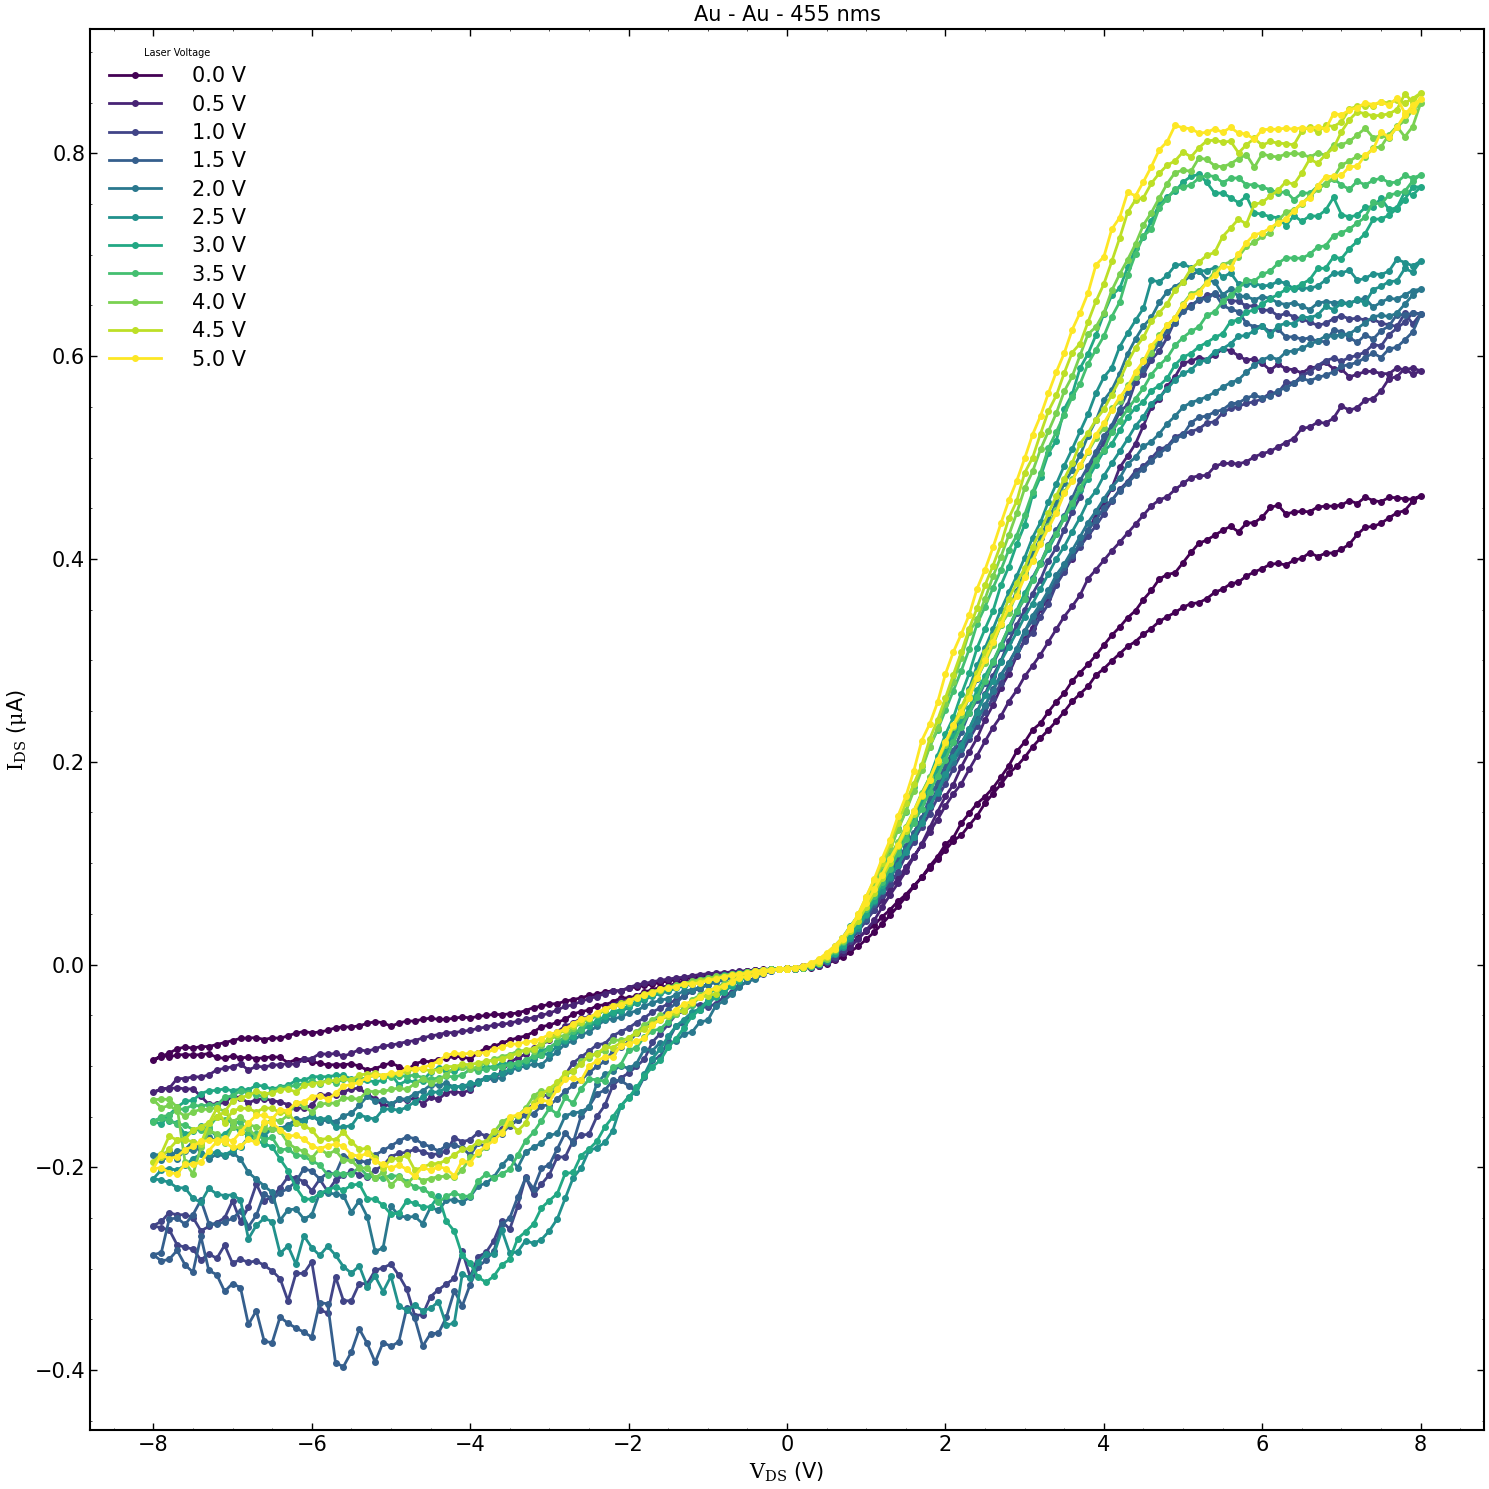

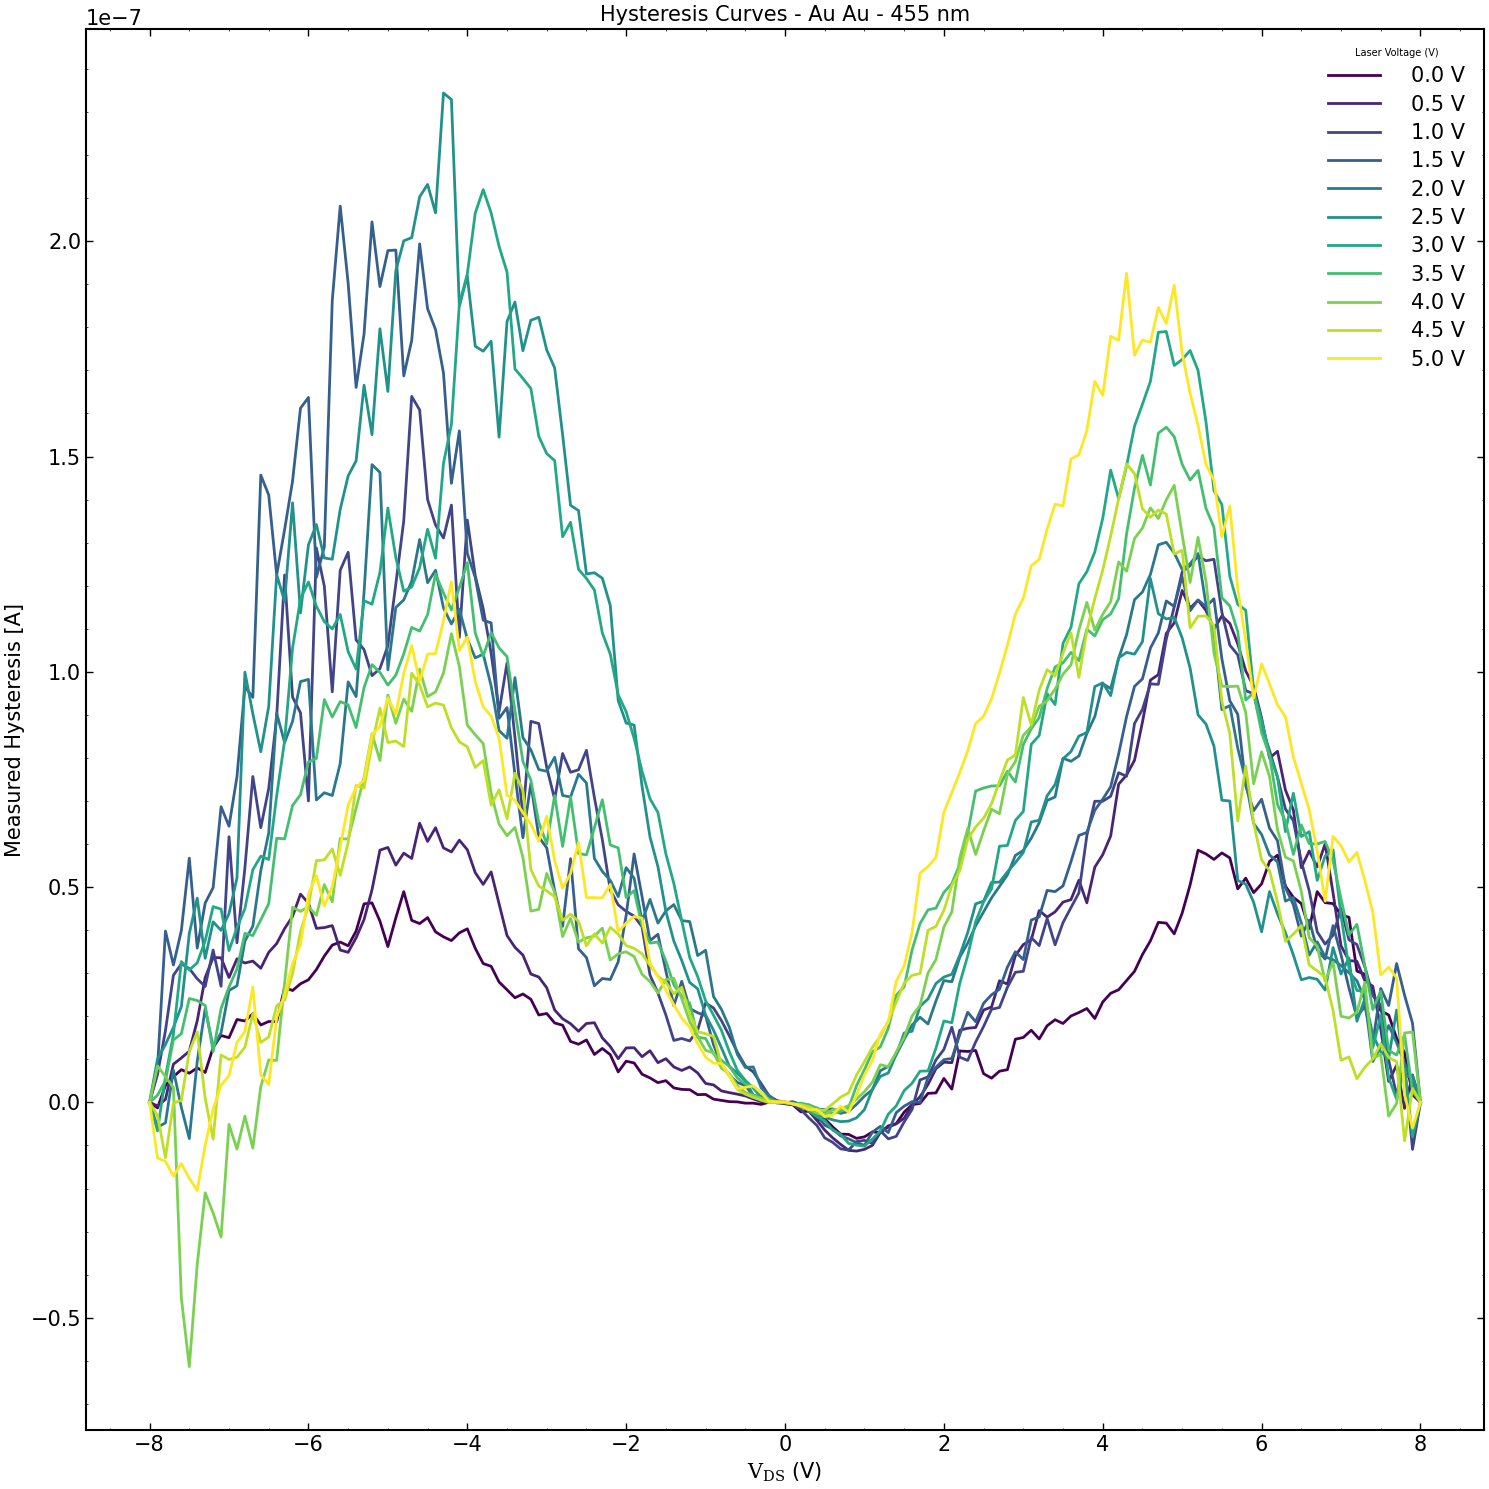

In [5]:
# === Filter and prepare data using the new helper ===
data_455_10um_up = filter_experiments(
    df=props_raw,
    date_prefix="2025-04-16",
    wavelength=455,
    info="SnS - 10 um - 455 - power up"
)

hyst_455_10um_up = filter_experiments(
    df=props_hyst,
    date_prefix="2025-04-16",
    wavelength=455,
    info="SnS - 10 um - 455 - power up"
)

# === Generate a colormap ===
n = len(data_455_10um_up)
colors = cm.viridis(np.linspace(0, 1, n))

# === Plot raw current vs Vsd ===
fig, ax = plt.subplots(figsize=(15, 15))

for i, (idx, row) in enumerate(data_455_10um_up.iterrows()):
    key = row["data_key"]
    df = data_raw[key]()
    df["I (A)"] *= 1e6  # Convert to μA

    x, y = df[["Vsd (V)", "I (A)"]].values.T
    label = f'{row["Laser voltage"]:.1f} V'

    ax.plot(x, y, label=label, color=colors[i], marker='o', markersize=4)

ax.set_ylabel("$\\rm I_{DS}$ ($\\rm \mu$A)")
ax.set_xlabel("$\\rm V_{DS}$ (V)")
ax.set_title("Au - Au - 455 nms")
ax.legend(title="Laser Voltage", loc="best")
fig.tight_layout()
plt.savefig("Au_Au_455_up.png", dpi=300)
plt.show()

# === Plot hysteresis curves ===
fig, ax = plt.subplots(figsize=(15, 15))

for i, (_, row) in enumerate(hyst_455_10um_up.iterrows()):
    data_key = row["data_key"]
    laser_voltage = row["Laser voltage"]
    df = data_hyst[data_key]()

    # Use second column as Y, with its name
    y_col = df.columns[1]
    ax.plot(df["Vsd (V)"], df[y_col], label=f'{laser_voltage:.1f} V', color=colors[i])

ax.set_xlabel("$\\rm V_{DS}$ (V)")
ax.set_ylabel("Measured Hysteresis [A]")
ax.set_title("Hysteresis Curves - Au Au - 455 nm")
ax.legend(title="Laser Voltage (V)")
fig.tight_layout()
plt.savefig("hysteresis_Au_Au_455_up.png", dpi=300)
plt.show()


<Axes: xlabel='Laser voltage'>

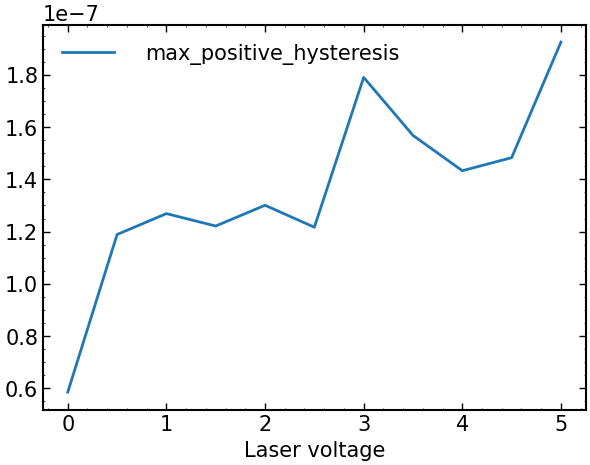

In [6]:
hyst_455_10um_up.plot(x="Laser voltage", y="max_positive_hysteresis")

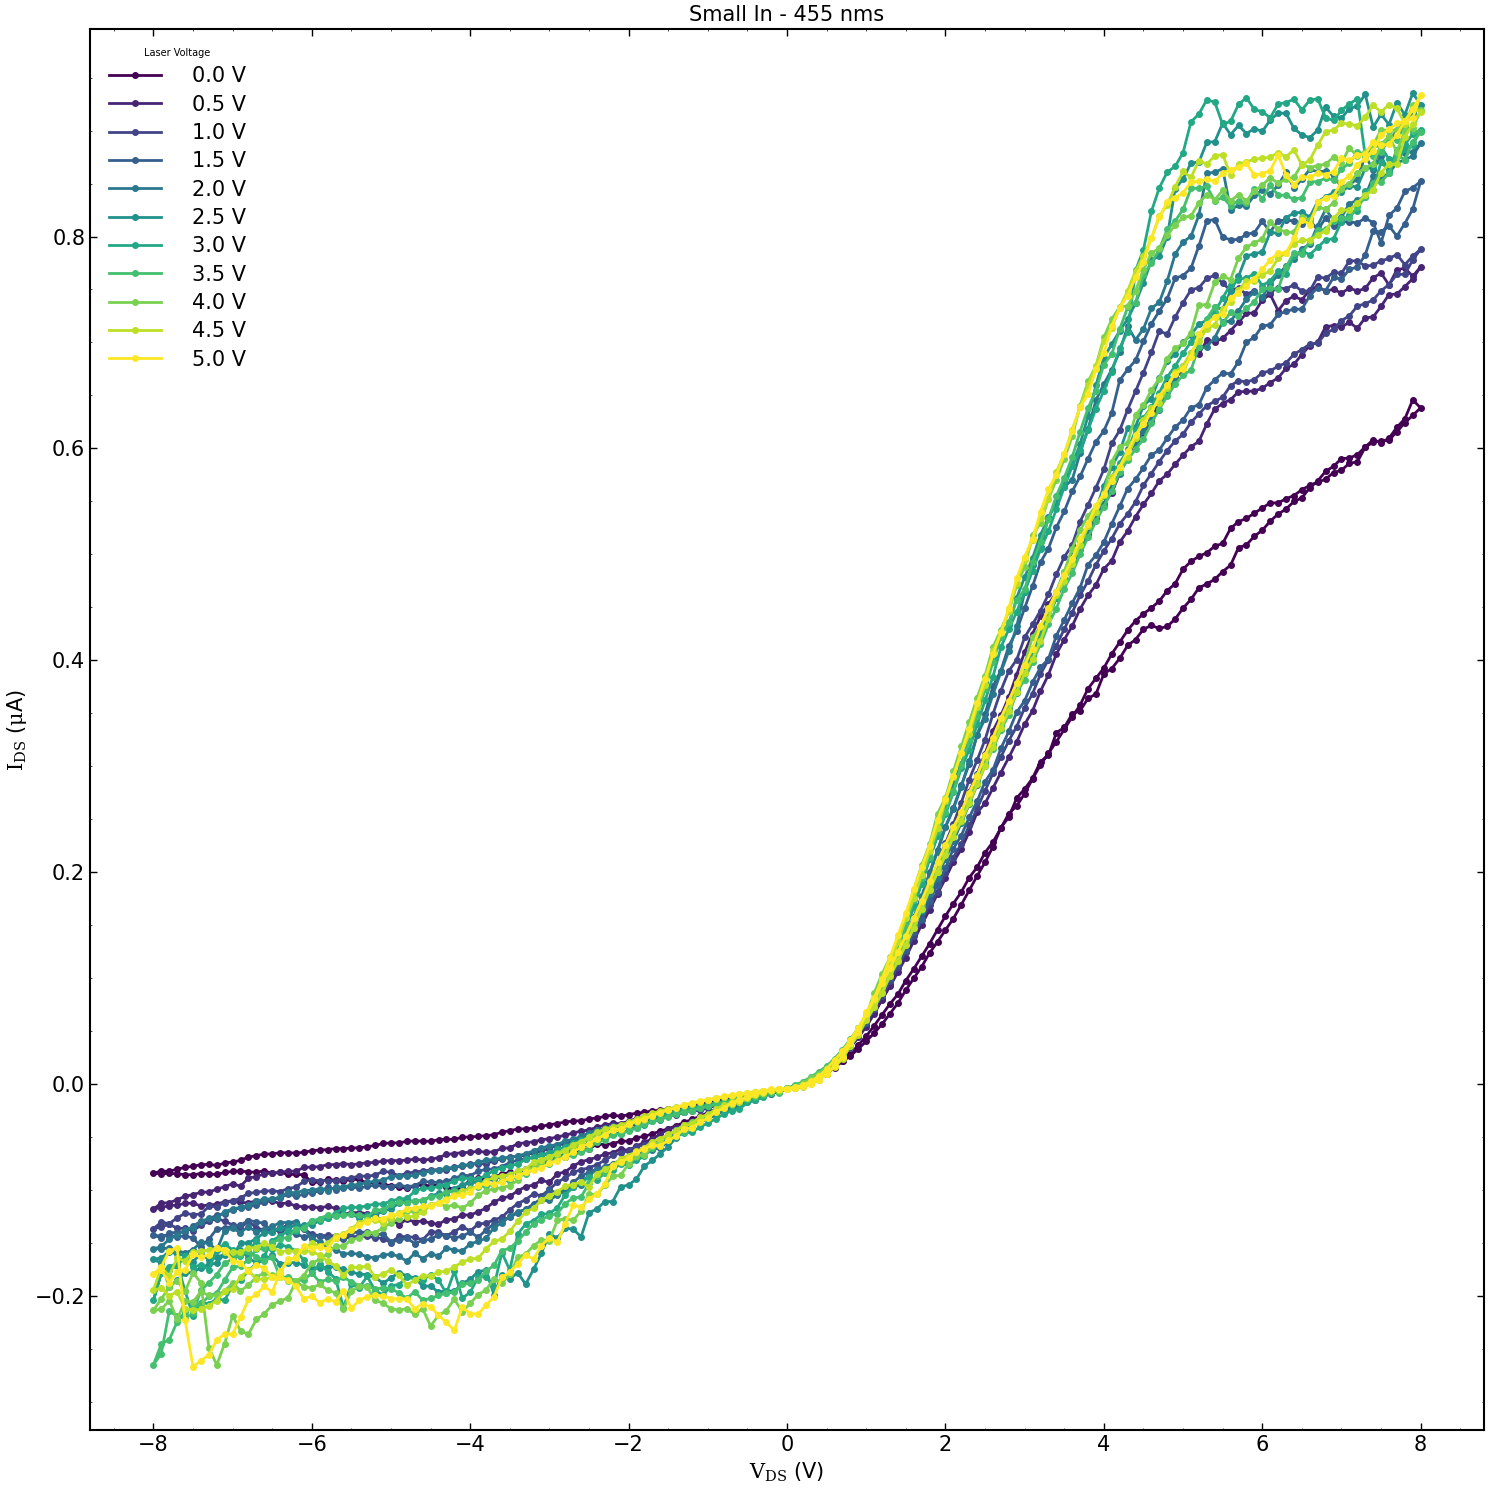

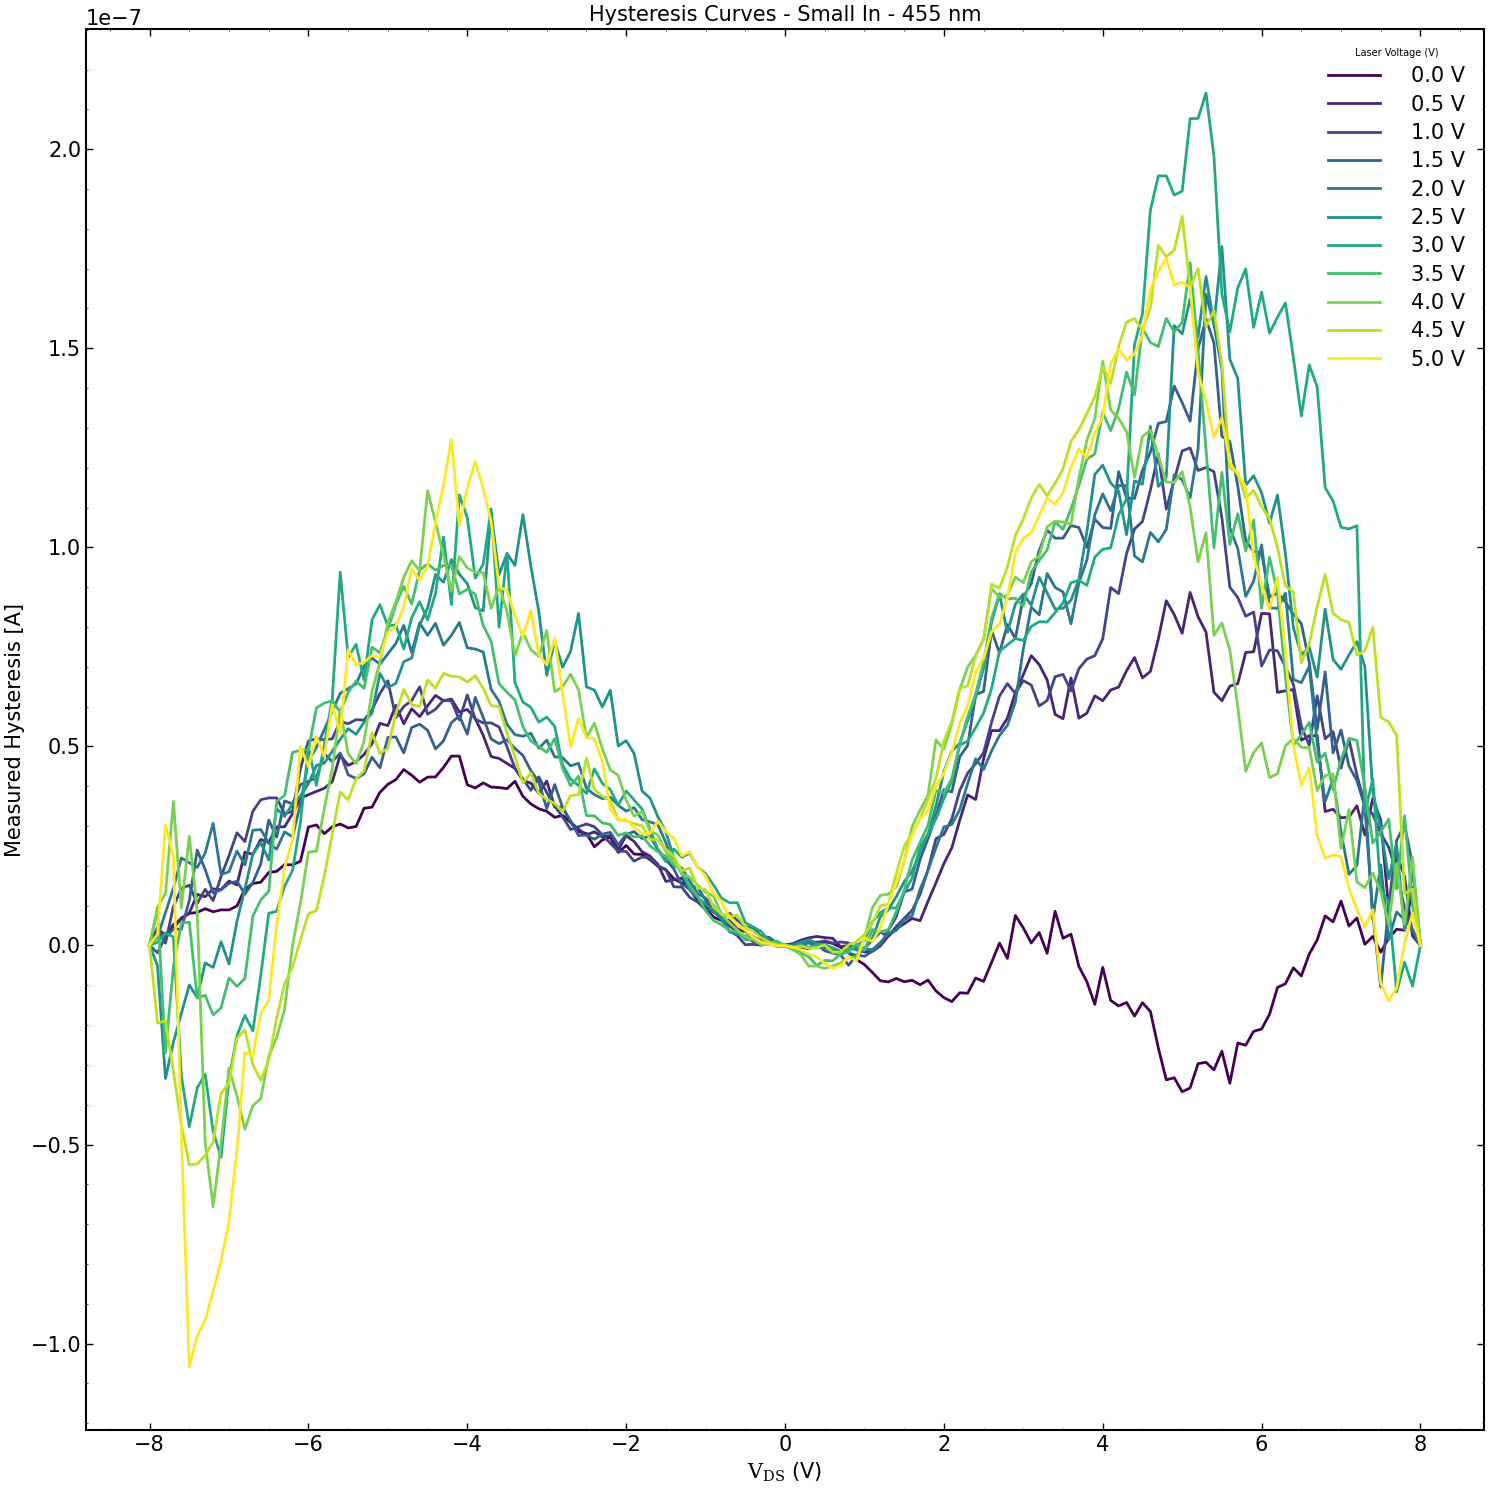

In [7]:
# === Filter and prepare data using the new helper ===
data_455_10um_down = filter_experiments(
    df=props_raw,
    date_prefix="2025-04-16",
    wavelength=455,
    info="SnS - 10 um - 455 - power down"
)

hyst_455_10um_down = filter_experiments(
    df=props_hyst,
    date_prefix="2025-04-16",
    wavelength=455,
    info="SnS - 10 um - 455 - power down"
)

# === Generate a colormap ===
n = len(data_455_10um_down)
colors = cm.viridis(np.linspace(0, 1, n))

# === Plot raw current vs Vsd ===
fig, ax = plt.subplots(figsize=(15, 15))

for i, (idx, row) in enumerate(data_455_10um_down.iterrows()):
    key = row["data_key"]
    df = data_raw[key]()
    df["I (A)"] *= 1e6  # Convert to μA

    x, y = df[["Vsd (V)", "I (A)"]].values.T
    label = f'{row["Laser voltage"]:.1f} V'

    ax.plot(x, y, label=label, color=colors[i], marker='o', markersize=4)

ax.set_ylabel("$\\rm I_{DS}$ ($\\rm \mu$A)")
ax.set_xlabel("$\\rm V_{DS}$ (V)")
ax.set_title("Small In - 455 nms")
ax.legend(title="Laser Voltage", loc="best")
fig.tight_layout()
plt.savefig("Small_In.png", dpi=300)
plt.show()

# === Plot hysteresis curves ===
fig, ax = plt.subplots(figsize=(15, 15))

for i, (_, row) in enumerate(hyst_455_10um_down.iterrows()):
    data_key = row["data_key"]
    laser_voltage = row["Laser voltage"]
    df = data_hyst[data_key]()

    # Use second column as Y, with its name
    y_col = df.columns[1]
    ax.plot(df["Vsd (V)"], df[y_col], label=f'{laser_voltage:.1f} V', color=colors[i])

ax.set_xlabel("$\\rm V_{DS}$ (V)")
ax.set_ylabel("Measured Hysteresis [A]")
ax.set_title("Hysteresis Curves - Small In - 455 nm")
ax.legend(title="Laser Voltage (V)")
fig.tight_layout()
plt.savefig("hysteresis_Small_In_455_up.png", dpi=300)
plt.show()


<Axes: xlabel='Laser voltage'>

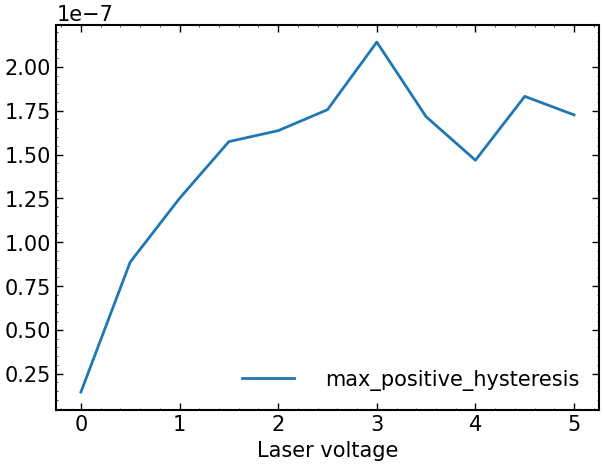

In [8]:
hyst_455_10um_down.plot(x="Laser voltage", y="max_positive_hysteresis")

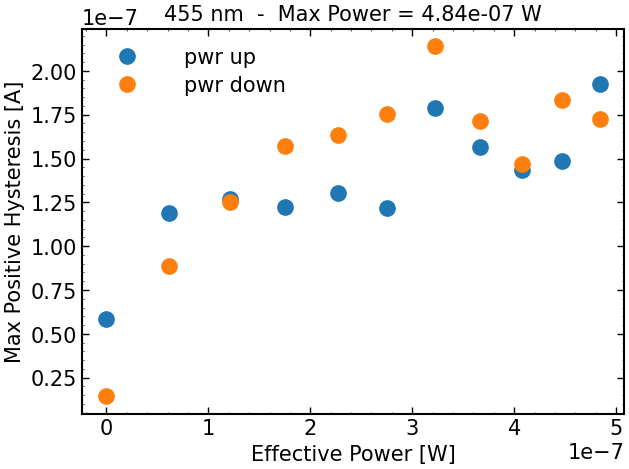

In [9]:

wl = 455

# 1) Convert Laser voltage → LED power in the first DataFrame
hyst_455_10um_up["LED power"] = hyst_455_10um_up["Laser voltage"].apply(calibration_fns[wl]) * factor


# 2) Plot the first dataset, capturing the Axes
ax = hyst_455_10um_up.plot(
    x="LED power", 
    y="max_positive_hysteresis", 
    style="o", 
    label="pwr up"
)

# 3) Convert Laser voltage → LED power in the second DataFrame
hyst_455_10um_down["LED power"] = hyst_455_10um_down["Laser voltage"].apply(calibration_fns[wl]) * factor

# 4) Plot the second dataset on the same Axes
hyst_455_10um_down.plot(
    x="LED power", 
    y="max_positive_hysteresis", 
    style="o", 
    label="pwr down", 
    ax=ax
)
# 3) Find max power row
max_idx = hyst_455_10um_down["LED power"].idxmax()
max_power = hyst_455_10um_down.loc[max_idx, "LED power"]
max_hyst = hyst_455_10um_down.loc[max_idx, "max_positive_hysteresis"]


# (Optional) Customize the figure
plt.title(f"455 nm  -  Max Power = {max_power:.2e} W")
plt.xlabel("Effective Power [W]")
plt.ylabel("Max Positive Hysteresis [A]")
plt.savefig("455_small_In_needle.png")
plt.show()
